# Importing the libraries files and dataset
preparing the data

In [15]:
# import pandas as pd # used for data manipulation and analysis
# import numpy as np # used for numerical and scientific computing for large multi dimensional arrays and matrices
# import matplotlib.pyplot as plt # Importing Matplotlib's pyplot module for plotting and data visualization
# import seaborn as sns # Importing Seaborn for advanced statistical data visualization

# from sklearn.model_selection import train_test_split, cross_val_score # Importing functions to split data and evaluate models using cross-validation
# from sklearn.preprocessing import LabelEncoder, StandardScaler # Importing tools to encode categorical labels and scale features for normalization
# # Importing evaluation metrics for classification model performance analysis
# from sklearn.metrics import (
#     classification_report,
#     confusion_matrix,
#     roc_auc_score,
#     roc_curve,
#     ConfusionMatrixDisplay
# )


# from sklearn.linear_model import LogisticRegression # Importing Logistic Regression model for binary or multiclass classification tasks
# from sklearn.ensemble import RandomForestClassifier # Importing Random Forest model, an ensemble method for robust and accurate classification
# from xgboost import XGBClassifier # Importing XGBoost classifier, a high-performance gradient boosting algorithm for classification tasks
# from sklearn.svm import SVC # Importing Support Vector Classifier for classification using hyperplanes in high-dimensional space
# from sklearn.neighbors import KNeighborsClassifier # Importing K-Nearest Neighbors algorithm for instance-based classification

# input_file = '/content/Dataset.xlsx'
# df = pd.read_excel(input_file)
# df

In [16]:
# !pip install "scikeras>=0.12.0,<0.13" "scikit-learn>=1.2.2,<1.3"

# !pip uninstall numpy scikit-learn -y
# !pip install numpy==1.26.4 scikit-learn==1.4.1

# Importing dataset

In [17]:
import pandas as pd # used for data manipulation and analysis
# input_file = '/content/Dataset1.xlsx'
input_file = "E:\Work\FT\Job Hunting\Portfolio\predictive-maintenance-ml\data\Dataset1.xlsx"
# Load the Excel dataset into a DataFrame
df = pd.read_excel(input_file)
# Display the first 5 rows to inspect data structure
print(df.head())



   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

# General overview of dataset

In [18]:
df.head()         # Shows the first 5 rows
df.tail()         # Shows the last 5 rows
df.sample(5)      # Random 5 samples
df.shape          # Returns (rows, columns)
df.columns        # Lists all column names
df.index          # Shows the row index range

RangeIndex(start=0, stop=10000, step=1)

In [19]:
# Print dataset shape (rows, columns) and list of column names
print("Shape:", df.shape)
print("Columns:", list(df.columns))


Shape: (10000, 14)
Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


# Info and datatype

In [20]:
# df.info()         # Summary: columns, data types, non-null counts
df.dtypes         # Data types of each column
df.select_dtypes(include='object')  # Only categorical columns
df.select_dtypes(include='number')  # Only numeric columns


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [21]:
# Get data type and non-null count for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

# Descriptive Statistics

In [22]:
df.describe()     # Stats summary for numerical columns
df.describe(include='object')  # Summary for categorical columns
df.nunique()      # Number of unique values per column


UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [23]:
# Basic descriptive statistics for numeric columns
print(df.describe())


               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.037500   
std                179.284096      9.968934        63.654147         0.189993   
min               1168.000000      3.800000         0.000000   

# Missing Values

In [24]:
df.isnull().sum()           # Total missing values per column
df.isnull().mean() * 100    # % of missing values per column
df[df.isnull().any(axis=1)] # Rows with at least one missing value


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF


In [25]:
# Calculate missing values count and percentage for each column
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
print(pd.concat([missing, missing_percent], axis=1, keys=['Missing', '%']))


                         Missing    %
UDI                            0  0.0
Product ID                     0  0.0
Type                           0  0.0
Air temperature [K]            0  0.0
Process temperature [K]        0  0.0
Rotational speed [rpm]         0  0.0
Torque [Nm]                    0  0.0
Tool wear [min]                0  0.0
Machine failure                0  0.0
TWF                            0  0.0
HDF                            0  0.0
PWF                            0  0.0
OSF                            0  0.0
RNF                            0  0.0


# Preliminary Analysis of the Target Variable

In [26]:
# Display counts and percentages for target classes
target_counts = df['Machine failure'].value_counts()
target_percent = df['Machine failure'].value_counts(normalize=True) * 100
print(pd.concat([target_counts, target_percent], axis=1, keys=['Count', '%']))


                 Count      %
Machine failure              
0                 9625  96.25
1                  375   3.75


# Preview the original DataFrame structure

In [27]:
print("Initial columns:", df.columns.tolist())
print("DataFrame shape before dropping columns:", df.shape)

Initial columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
DataFrame shape before dropping columns: (10000, 14)


# Drop columns that are identifiers and not predictive


In [28]:
cols_to_drop = ["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"]
df.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped columns: {cols_to_drop}")
print("DataFrame shape after dropping columns:", df.shape)


Dropped columns: ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
DataFrame shape after dropping columns: (10000, 7)


# Check for Duplicate Row

In [29]:
# Check for duplicates in the entire DataFrame
duplicate_rows = df[df.duplicated()]

# Display the duplicate rows
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
duplicates = df.duplicated().sum()
print(f"Duplicate records: {duplicates}")
print(duplicate_rows.head())

# Remove duplicate rows (if any)
df = df.drop_duplicates().reset_index(drop=True)


Number of duplicate rows: 0
Duplicate records: 0
Empty DataFrame
Columns: [Type, Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min], Machine failure]
Index: []


# Exploratory Data Analysis (EDA)

##  Establishing a Consistent Visual Style

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
# Set a consistent style for all plots
sns.set_style("whitegrid")
sns.set(style="whitegrid")


# Check unique values in 'Type' before encoding

In [31]:
print("\nUnique values in 'Type' before encoding:")
print(df['Type'].value_counts())


Unique values in 'Type' before encoding:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


# Encode categorical feature 'Type' using LabelEncoder

In [32]:
!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Type'] = label_encoder.fit_transform(df['Type'])

# Show mapping of labels
type_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nLabel encoding mapping for 'Type':", type_mapping)


Label encoding mapping for 'Type': {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


## Target Variable Distribution



C:\Users\Hp\AppData\Local\Temp\ipykernel_11940\432578143.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine failure', data=df, palette="Set2")


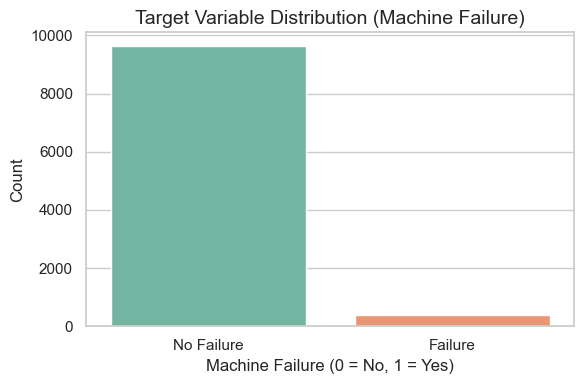

In [33]:
# Target Variable Distribution
# This shows how many machines failed vs. how many did not
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df, palette="Set2")
plt.title("Target Variable Distribution (Machine Failure)", fontsize=14)
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Failure", "Failure"])
plt.tight_layout()
plt.show()
# This plot helps to understand class imbalance.


## Correlation Heatmap

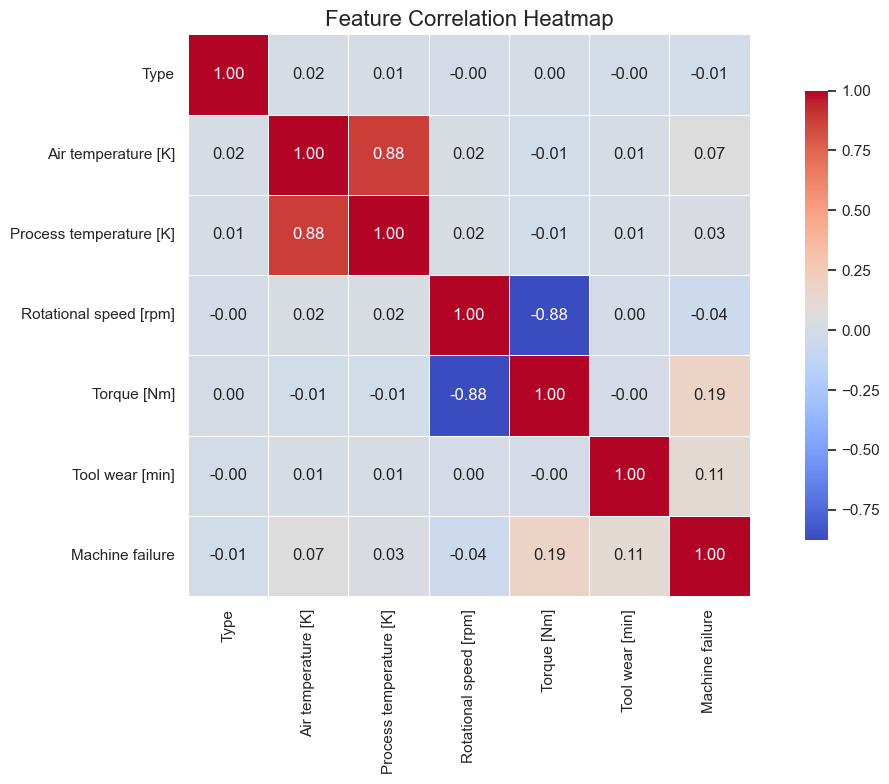

In [34]:
# Correlation Heatmap
# Visualize pairwise correlation between numerical features
plt.figure(figsize=(12, 8))

# Compute correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot heatmap with annotations
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## Failure Rate by Machine Type

C:\Users\Hp\AppData\Local\Temp\ipykernel_11940\2133949672.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Type", y="Machine failure", data=df, palette="pastel", ci=None)
C:\Users\Hp\AppData\Local\Temp\ipykernel_11940\2133949672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Type", y="Machine failure", data=df, palette="pastel", ci=None)


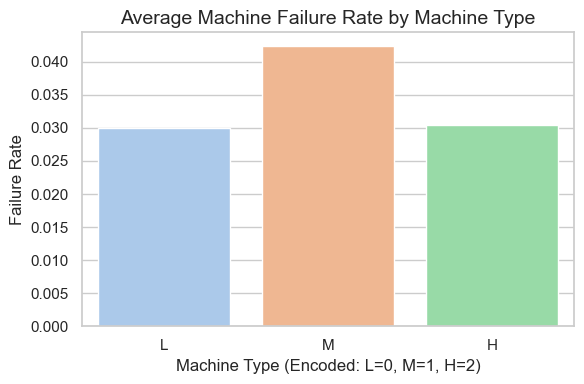

In [35]:
# Failure Rate by Machine Type
# Visualizes how machine failure rate varies by 'Type' (already label encoded)
plt.figure(figsize=(6, 4))

# Plot average failure rate per machine type
sns.barplot(x="Type", y="Machine failure", data=df, palette="pastel", ci=None)

plt.title("Average Machine Failure Rate by Machine Type", fontsize=14)
plt.xlabel("Machine Type (Encoded: L=0, M=1, H=2)")
plt.ylabel("Failure Rate")
plt.xticks([0, 1, 2], ['L', 'M', 'H'])  # Map back to original labels for clarity
plt.tight_layout()
plt.show()

## Distribution of Numerical Features

> Add blockquote

> Add blockquote





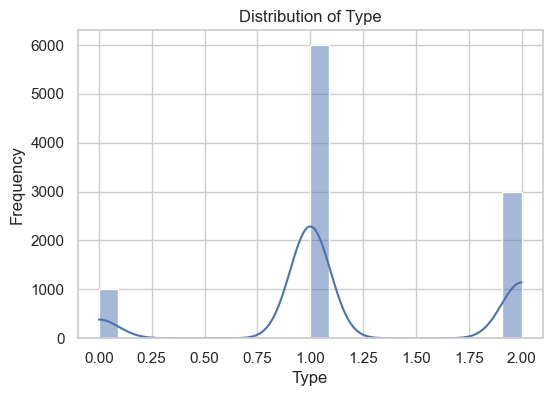

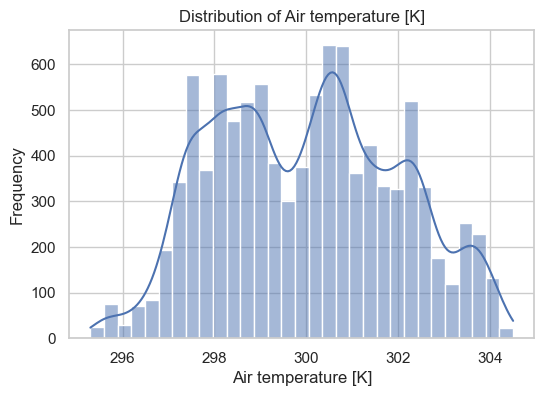

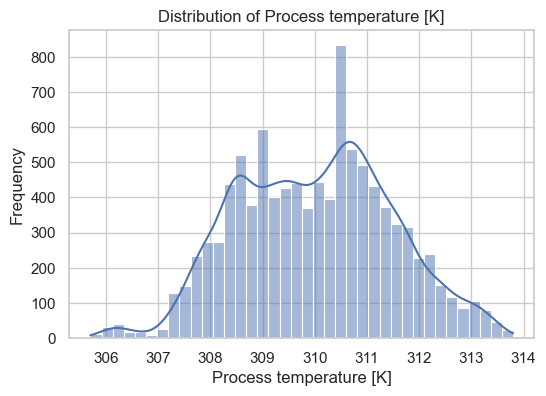

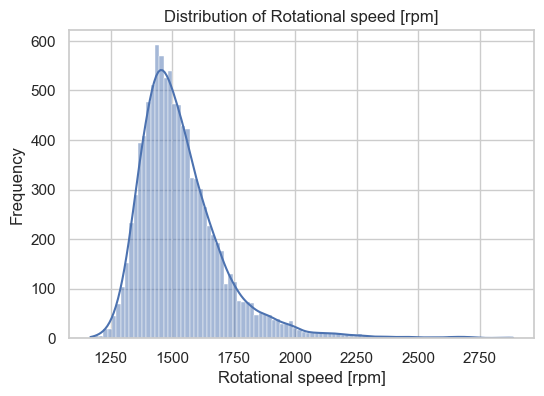

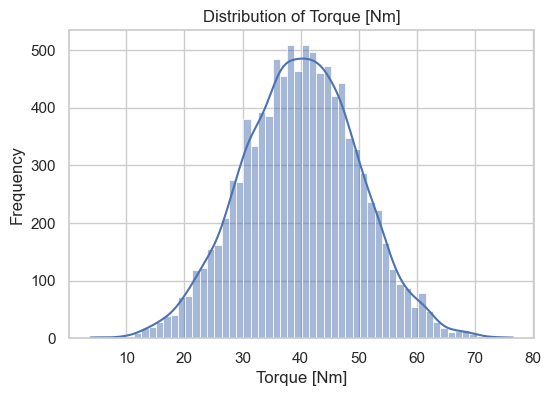

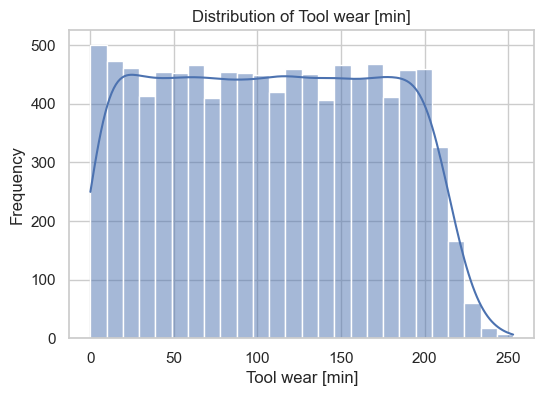

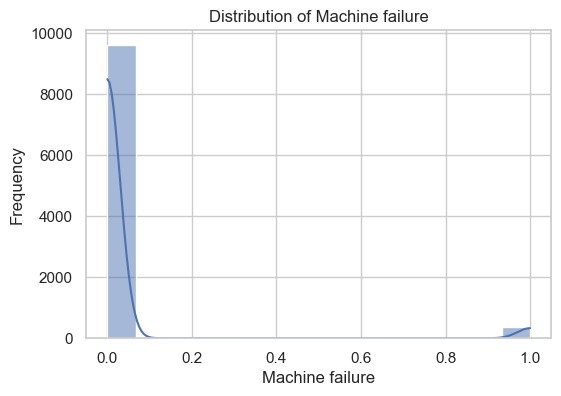

In [36]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


## Outlier Detection via Boxplots

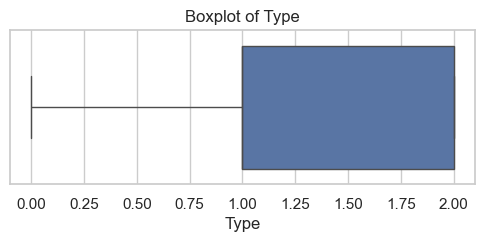

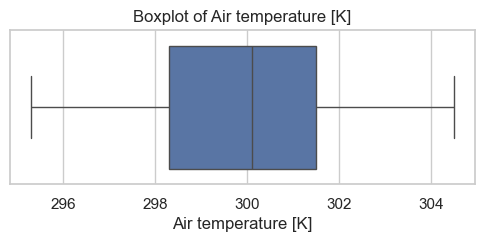

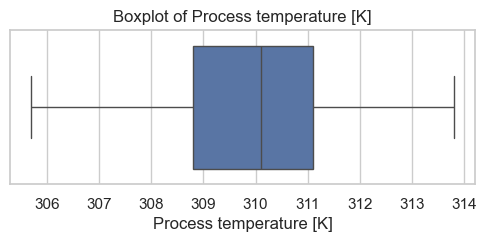

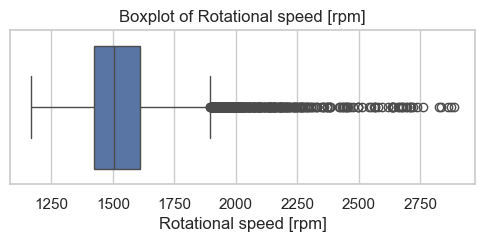

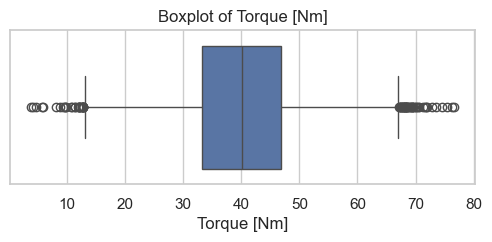

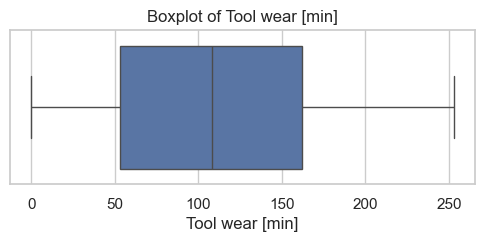

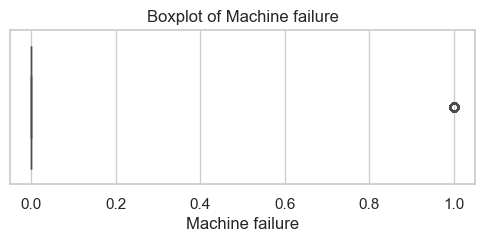

In [37]:
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


# Define features (X) and target (y)

In [38]:

target_col = "Machine failure"

# Ensure the target column exists
if target_col in df.columns:
    X = df.drop(columns=[target_col])
    y = df[target_col]
    print(f"\nTarget column '{target_col}' successfully separated.")
    print("Features shape:", X.shape)
    print("Target shape:", y.shape)
else:
    raise ValueError(f"Target column '{target_col}' not found in DataFrame")



Target column 'Machine failure' successfully separated.
Features shape: (10000, 6)
Target shape: (10000,)


# Display sample of features and target

In [39]:
print("\nSample features (X):")
print(X.head())

print("\nSample target (y):")
print(y.head())


Sample features (X):
   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     2                298.1                    308.6                    1551   
1     1                298.2                    308.7                    1408   
2     1                298.1                    308.5                    1498   
3     1                298.2                    308.6                    1433   
4     1                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  
2         49.4                5  
3         39.5                7  
4         40.0                9  

Sample target (y):
0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64


# Scalar, transform

In [40]:
# Initialize the scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on features (X) and transform them
#    This standardizes the data: mean = 0, standard deviation = 1
X_scaled = scaler.fit_transform(X)

# Convert scaled array back to a DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("\nScaled feature sample:")
print(X_scaled_df.head())





Scaled feature sample:
       Type  Air temperature [K]  Process temperature [K]  \
0  1.333889            -0.952389                -0.947360   
1 -0.332223            -0.902393                -0.879959   
2 -0.332223            -0.952389                -1.014761   
3 -0.332223            -0.902393                -0.947360   
4 -0.332223            -0.902393                -0.879959   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
0                0.068185     0.282200        -1.695984  
1               -0.729472     0.633308        -1.648852  
2               -0.227450     0.944290        -1.617430  
3               -0.590021    -0.048845        -1.586009  
4               -0.729472     0.001313        -1.554588  


## Splitting Data into Training and Testing Sets

In [41]:
from sklearn.model_selection import train_test_split
# Train-test split
#    - test_size=0.3: 30% of the data will be used as the test set
#    - random_state=42: ensures reproducibility
#    - stratify=y: maintains class distribution in train and test sets (important for imbalanced datasets)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Display the shapes of the resulting datasets
print("\nData split complete.")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

# Check class distribution in training and test sets
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nClass distribution in test set:")
print(pd.Series(y_test).value_counts(normalize=True))


Data split complete.
Training features shape: (7000, 6)
Testing features shape: (3000, 6)
Training labels shape: (7000,)
Testing labels shape: (3000,)

Class distribution in training set:
Machine failure
0    0.962429
1    0.037571
Name: proportion, dtype: float64

Class distribution in test set:
Machine failure
0    0.962667
1    0.037333
Name: proportion, dtype: float64


# Apply SMOTE to balance the target classes

In [42]:
# !pip install --upgrade scikit-learn imbalanced-learn


In [43]:
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. Apply SMOTE only to the training data (NOT the test data)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 3. Show the new class distribution
print("\n Class distribution AFTER applying SMOTE (on training set):")
print(pd.Series(y_train_resampled).value_counts())

# Compare shapes
print(f"\nOriginal X_train shape: {X_train.shape}")
print(f"Resampled X_train shape: {X_train_resampled.shape}")



 Class distribution AFTER applying SMOTE (on training set):
Machine failure
0    6737
1    6737
Name: count, dtype: int64

Original X_train shape: (7000, 6)
Resampled X_train shape: (13474, 6)


# Define Models and Imports

In [44]:
!pip install xgboost

In [45]:
from sklearn.linear_model import LogisticRegression # Importing Logistic Regression model for binary or multiclass classification tasks
from sklearn.ensemble import RandomForestClassifier # Importing Random Forest model, an ensemble method for robust and accurate classification
from xgboost import XGBClassifier # Importing XGBoost classifier, a high-performance gradient boosting algorithm for classification tasks
from sklearn.svm import SVC # Importing Support Vector Classifier for classification using hyperplanes in high-dimensional space
from sklearn.neighbors import KNeighborsClassifier # Importing K-Nearest Neighbors algorithm for instance-based classification

# Define the models to evaluate
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}


In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Model 1: Logistic Regression

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Parameters: {'C': 1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best ROC AUC (CV): 0.8869

Confusion Matrix:
[[2363  525]
 [  34   78]]


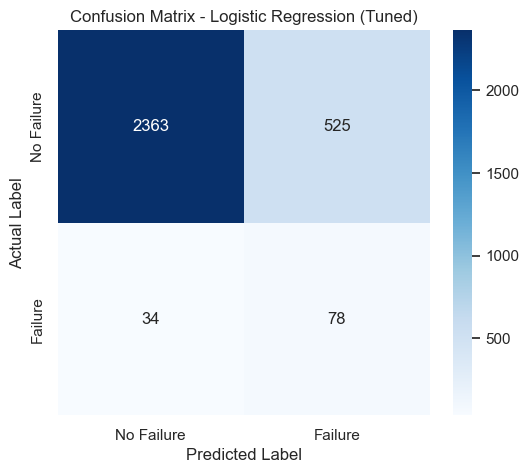


Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.82      0.89      2888
     Failure       0.13      0.70      0.22       112

    accuracy                           0.81      3000
   macro avg       0.56      0.76      0.56      3000
weighted avg       0.95      0.81      0.87      3000


ROC AUC Score (Test): 0.8392


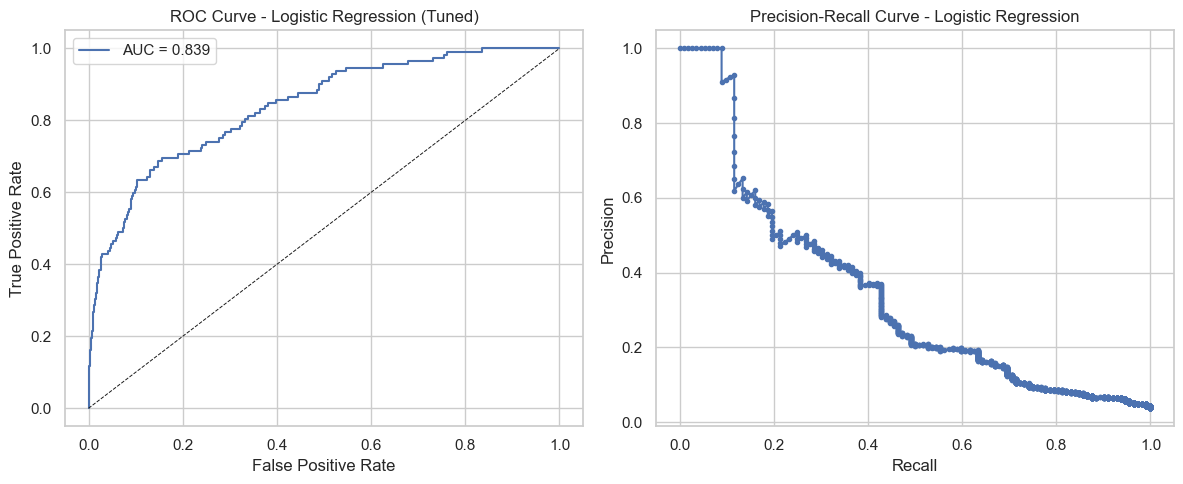

C:\Users\Hp\AppData\Local\Temp\ipykernel_11940\3693147832.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x="Coefficient", y="Feature", palette="coolwarm")


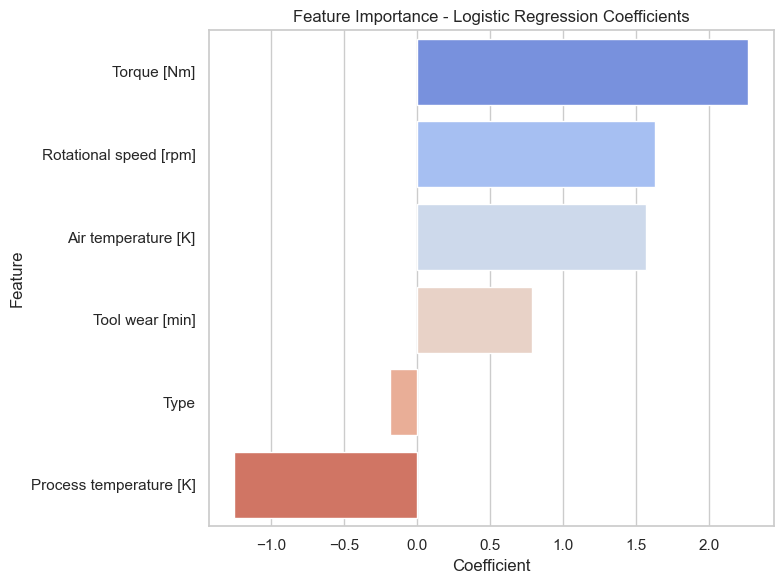

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

sns.set_style("whitegrid")

# ==============================
# 1. Define Parameter Grid
# ==============================
param_grid = {
    'penalty': ['l1', 'l2'],                 # Regularization type
    'C': [0.01, 0.1, 1, 10, 100],            # Inverse regularization strength
    'solver': ['liblinear', 'saga'],         # Solvers that support l1/l2
    'max_iter': [100, 200, 500]              # Iterations for convergence
}

# ==============================
# 2. Initialize Logistic Regression
# ==============================
log_reg = LogisticRegression(random_state=42)

# ==============================
# 3. Grid Search with 5-fold CV (ROC AUC scoring)
# ==============================
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    error_score='raise'   # raise errors during fitting to help debugging
)

# Fit on resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

# ==============================
# 4. Get best model
# ==============================
best_model = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)
print(f"Best ROC AUC (CV): {grid_search.best_score_:.4f}")

# Predictions on untouched test set
y_pred = best_model.predict(X_test)

# Get positive-class probabilities robustly (handle 1D or 2D outputs)
_proba = best_model.predict_proba(X_test)
if _proba.ndim == 2 and _proba.shape[1] >= 2:
    y_proba = _proba[:, 1]
else:
    y_proba = _proba.ravel()

# ==============================
# 5. Evaluation - Confusion matrix & report
# ==============================
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])
plt.title("Confusion Matrix - Logistic Regression (Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

# ROC AUC
auc = roc_auc_score(y_test, y_proba)
print(f"\nROC AUC Score (Test): {auc:.4f}")

# ==============================
# 6. ROC & Precision-Recall Curves
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12,5))

# ROC Curve
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Tuned)")
plt.legend()

# Precision-Recall Curve
plt.subplot(1,2,2)
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")

plt.tight_layout()
plt.show()

# ==============================
# 7. Feature Importance (Coefficients)
# ==============================
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance, x="Coefficient", y="Feature", palette="coolwarm")
plt.title("Feature Importance - Logistic Regression Coefficients")
plt.tight_layout()
plt.show()


# Model 2: Random Forest

Fitting 5 folds for each of 72 candidates, totalling 360 fits

 Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
 Best ROC AUC (CV): 0.9979

 Confusion Matrix:
[[2811   77]
 [  40   72]]


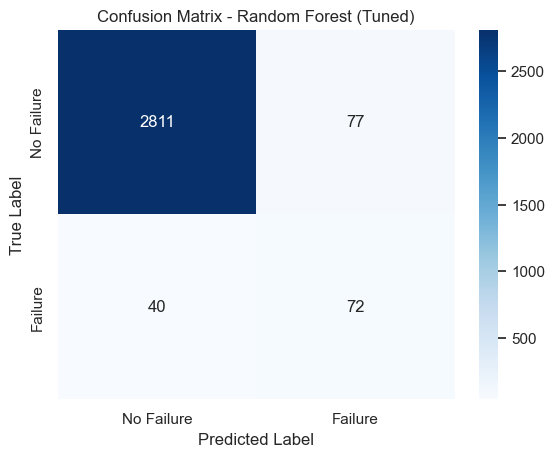


 Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      2888
     Failure       0.48      0.64      0.55       112

    accuracy                           0.96      3000
   macro avg       0.73      0.81      0.77      3000
weighted avg       0.97      0.96      0.96      3000

ROC AUC Score (Test): 0.9184


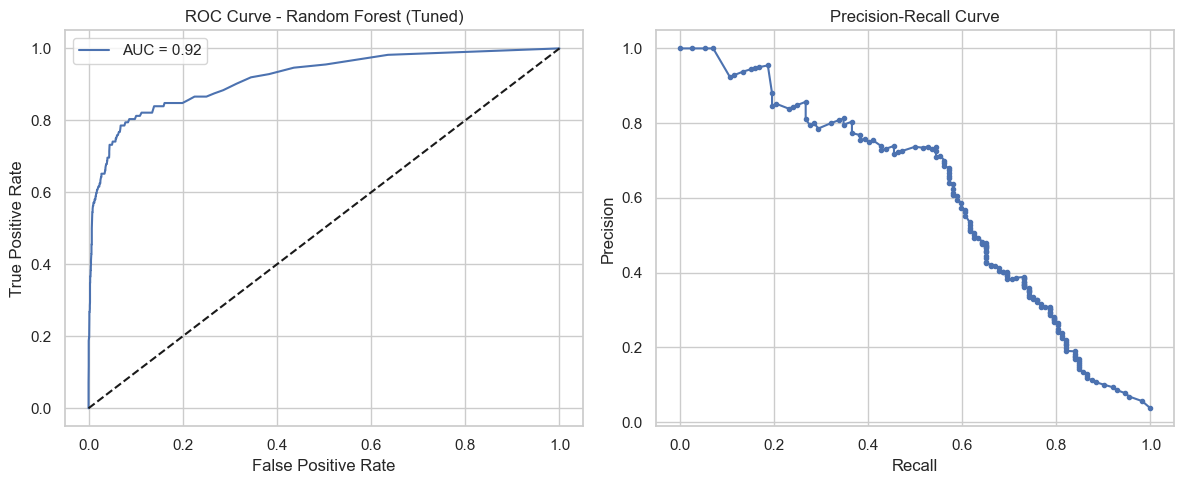

C:\Users\Hp\AppData\Local\Temp\ipykernel_11940\1546641792.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="viridis")


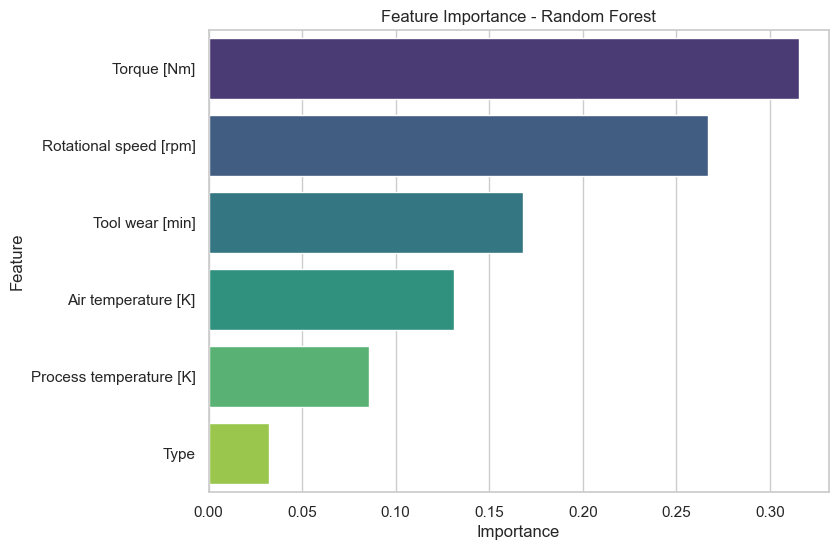

In [49]:
from sklearn.ensemble import RandomForestClassifier

# ==============================
# 1. Define Parameter Grid
# ==============================
param_grid = {
    'n_estimators': [100, 200],      # number of trees
    'max_depth': [None, 10, 20],      # maximum depth of trees
    'min_samples_split': [2, 5],      # min samples required to split a node
    'min_samples_leaf': [1, 2, 4],        # min samples per leaf
    'max_features': ['sqrt', 'log2']      # number of features to consider at each split
}

# ==============================
# 2. Initialize Random Forest
# ==============================
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# ==============================
# 3. Grid Search with 5-fold CV
# ==============================
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit on resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

# ==============================
# 4. Get Best Model
# ==============================
best_model = grid_search.best_estimator_

print("\n Best Parameters:", grid_search.best_params_)
print(f" Best ROC AUC (CV): {grid_search.best_score_:.4f}")

# Predictions on untouched test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# ==============================
# 5. Evaluation
# ==============================
print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score (Test): {auc:.4f}")

# ==============================
# 6. ROC & Precision-Recall Curves
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12,5))

# ROC Curve
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Tuned)")
plt.legend()

# Precision-Recall Curve
plt.subplot(1,2,2)
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

# ==============================
# 7. Feature Importance
# ==============================
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.show()


# Model3: XGBoost

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\Hp\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:44:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.7}
 Best ROC AUC (CV): 0.9983


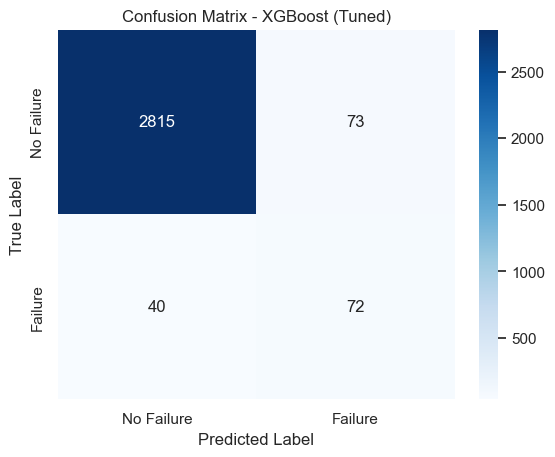


 Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      2888
     Failure       0.50      0.64      0.56       112

    accuracy                           0.96      3000
   macro avg       0.74      0.81      0.77      3000
weighted avg       0.97      0.96      0.96      3000

ROC AUC Score (Test): 0.9204


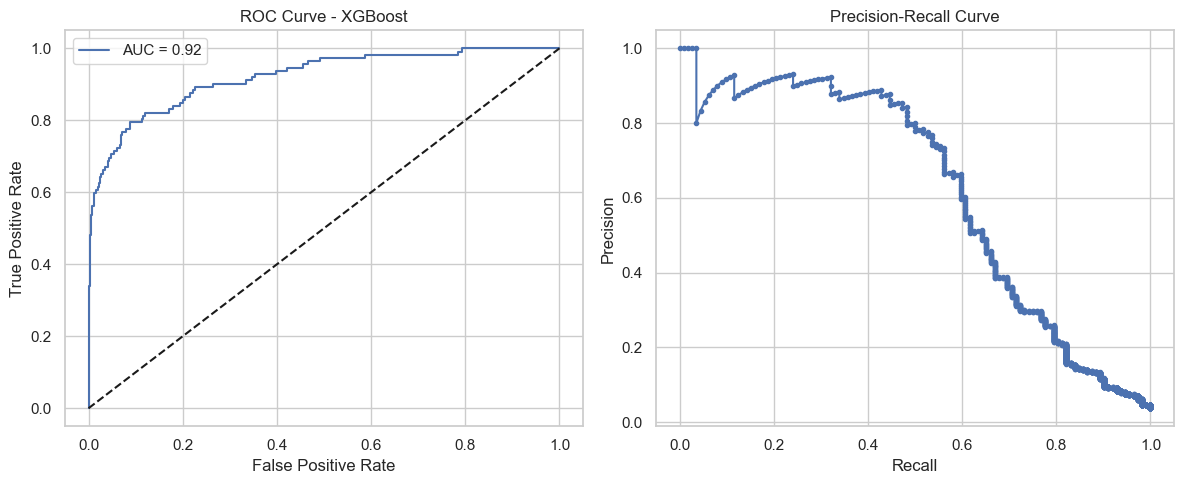

<Figure size 1000x600 with 0 Axes>

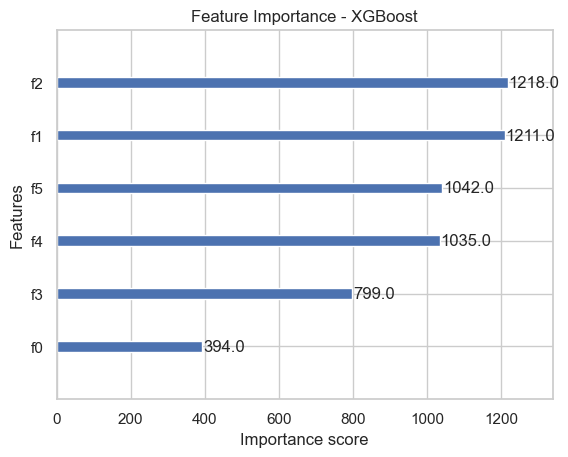

In [50]:
from xgboost import XGBClassifier, plot_importance


# ==============================
# 1. Define Parameter Grid
# ==============================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 1.0],
}

# ==============================
# 2. Initialize XGBoost
# ==============================
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# ==============================
# 3. Grid Search
# ==============================
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)
best_model = grid_search.best_estimator_

print("\n Best Parameters:", grid_search.best_params_)
print(f" Best ROC AUC (CV): {grid_search.best_score_:.4f}")

# ==============================
# 4. Predictions & Evaluation
# ==============================
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])
plt.title("Confusion Matrix - XGBoost (Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score (Test): {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

# ==============================
# 5. Feature Importance
# ==============================
plt.figure(figsize=(10,6))
plot_importance(best_model, importance_type='weight', max_num_features=15)
plt.title("Feature Importance - XGBoost")
plt.show()


# Model 4: SVM

Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
 Best ROC AUC (CV): 0.9773


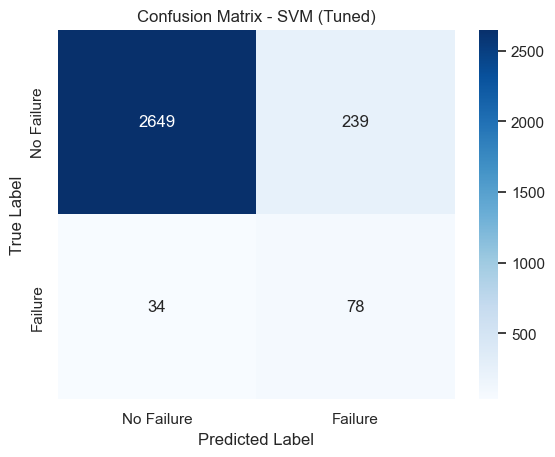


 Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.92      0.95      2888
     Failure       0.25      0.70      0.36       112

    accuracy                           0.91      3000
   macro avg       0.62      0.81      0.66      3000
weighted avg       0.96      0.91      0.93      3000

ROC AUC Score (Test): 0.8956


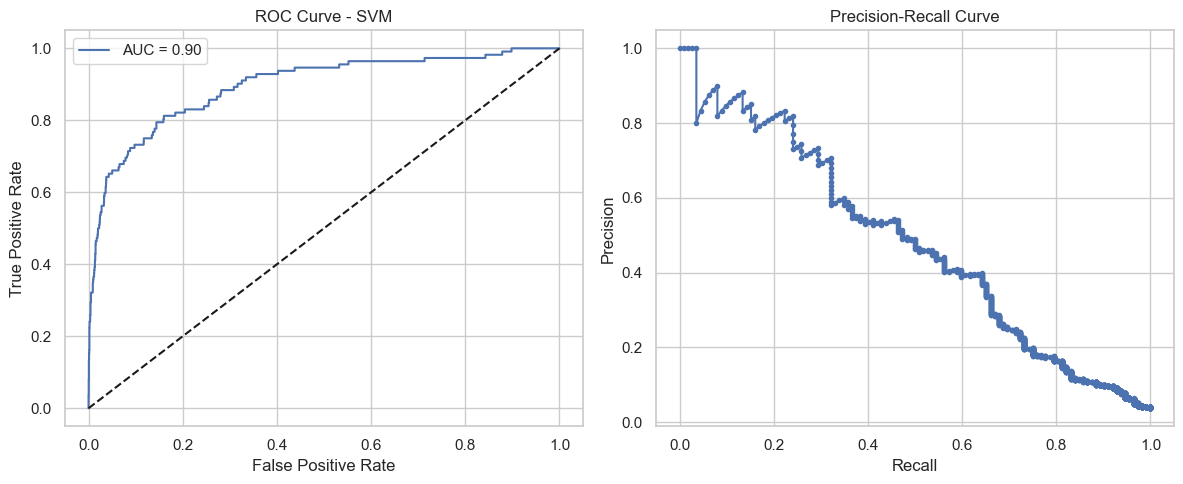

In [51]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. Define Parameter Grid
# ==============================
param_grid = {
    'C': [0.1, 1],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# ==============================
# 2. Initialize SVM
# ==============================
svm = SVC(probability=True, random_state=42)

# ==============================
# 3. Grid Search
# ==============================
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)
best_model = grid_search.best_estimator_

print("\n Best Parameters:", grid_search.best_params_)
print(f" Best ROC AUC (CV): {grid_search.best_score_:.4f}")

# ==============================
# 4. Predictions & Evaluation
# ==============================
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])
plt.title("Confusion Matrix - SVM (Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score (Test): {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()


# Model 5: K-Nearest Neighbors




Fitting 5 folds for each of 42 candidates, totalling 210 fits

 Best Parameters: {'metric': 'manhattan', 'n_neighbors': 25, 'weights': 'distance'}
 Best ROC AUC (CV): 0.9929


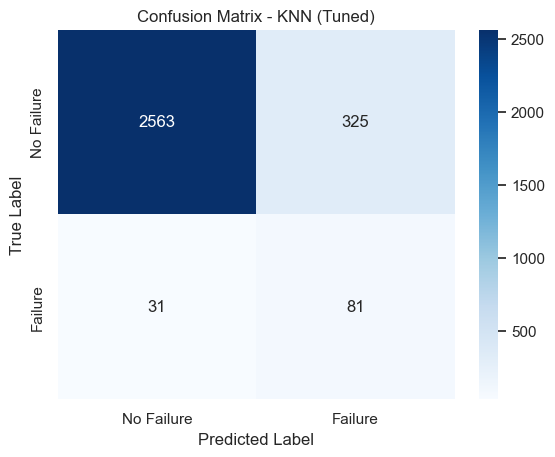


 Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.89      0.94      2888
     Failure       0.20      0.72      0.31       112

    accuracy                           0.88      3000
   macro avg       0.59      0.81      0.62      3000
weighted avg       0.96      0.88      0.91      3000

ROC AUC Score (Test): 0.8518


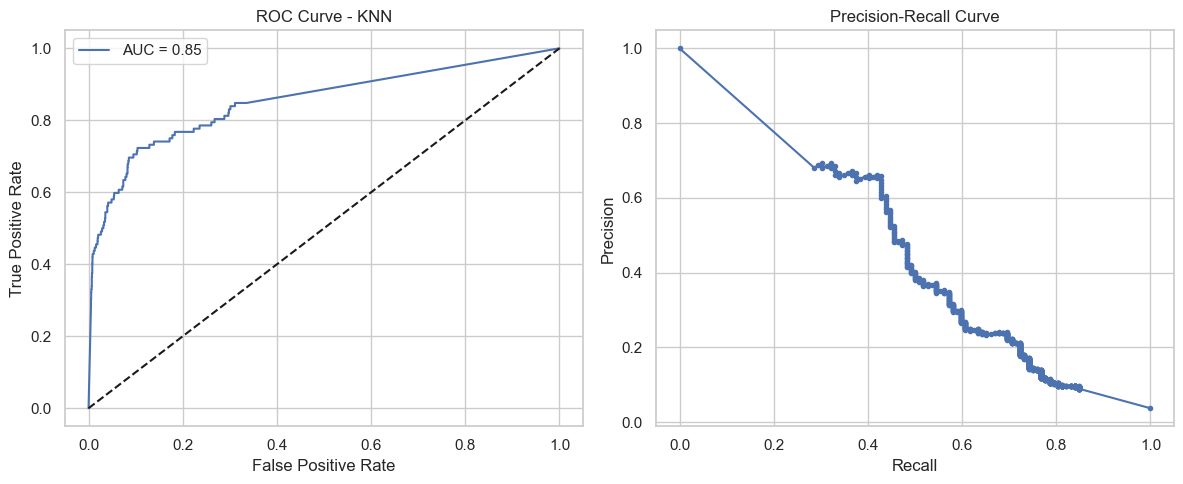

In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. Define Parameter Grid
# ==============================
param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 25, 100],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# ==============================
# 2. Initialize KNN
# ==============================
knn = KNeighborsClassifier()

# ==============================
# 3. Grid Search
# ==============================
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)
best_model = grid_search.best_estimator_

print("\n Best Parameters:", grid_search.best_params_)
print(f" Best ROC AUC (CV): {grid_search.best_score_:.4f}")

# ==============================
# 4. Predictions & Evaluation
# ==============================
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])
plt.title("Confusion Matrix - KNN (Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score (Test): {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()


# Model 6: K-Means clustering

C:\Users\Hp\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Hp\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Hp\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Hp\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

 Silhouette Score for k=2: 0.4223
 Silhouette Score for k=3: 0.2576
 Silhouette Score for k=4: 0.2556
 Silhouette Score for k=5: 0.2252

 Best k = 2 with Silhouette Score = 0.4223

 Failure Rate per Cluster:
Cluster
0    0.471148
1    0.504113
Name: Failure, dtype: float64


C:\Users\Hp\AppData\Local\Temp\ipykernel_11940\571559101.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=cluster_summary.values, palette="viridis")


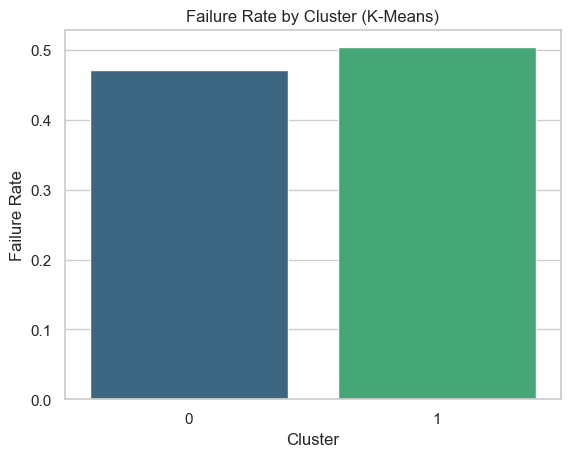

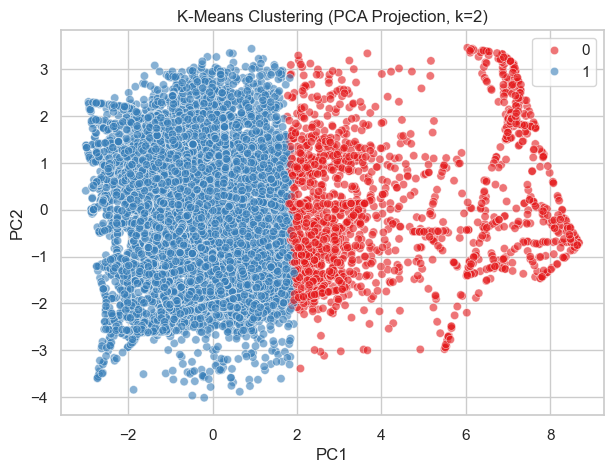

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================
# 1 Define range of clusters to try
# ==============================
range_n_clusters = [2, 3, 4, 5]

best_score = -1
best_k = None
best_clusters = None

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train_resampled)

    score = silhouette_score(X_train_resampled, cluster_labels)
    print(f" Silhouette Score for k={k}: {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k
        best_clusters = cluster_labels

print(f"\n Best k = {best_k} with Silhouette Score = {best_score:.4f}")

# ==============================
# 2 Add clusters to dataset
# ==============================
feature_names = ['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
train_with_clusters = pd.DataFrame(X_train_resampled, columns=feature_names)
train_with_clusters['Failure'] = y_train_resampled.values
train_with_clusters['Cluster'] = best_clusters

# Failure rate by cluster
cluster_summary = train_with_clusters.groupby("Cluster")['Failure'].mean()
print("\n Failure Rate per Cluster:")
print(cluster_summary)

# Barplot of failure rate per cluster
sns.barplot(x=cluster_summary.index, y=cluster_summary.values, palette="viridis")
plt.ylabel("Failure Rate")
plt.title("Failure Rate by Cluster (K-Means)")
plt.show()

# ==============================
# 3 Visualization (PCA projection to 2D)
# ==============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_resampled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=best_clusters, palette="Set1", alpha=0.6)
plt.title(f"K-Means Clustering (PCA Projection, k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

